In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [101]:
path_to_esc_results = Path("../esc_analysis")

all_model_results = list(path_to_esc_results.rglob("*barlow*kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("audioset_*/saved_vars*.pickle"))
# all_model_results

In [111]:
path_str = str(all_model_results[-2])
re.search(r'resnet([-\d]+)', path_str).group(1)

'18'

In [113]:
test_layers = [
                'input_after_preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]

def get_category_accuracies(predictions,labels,target):
    """
    Returns the accuracy for target category.
    """
    correct = 0
    total = 0
    for idx in range(len(labels)):
        label = labels[idx]
        if label==target:
            prediction = predictions[idx]
            if label==prediction:
                correct = correct+1
            total = total+1
    return correct/total


def format_model_str(path):
    path_str = str(path)
    task = 'equivariant' if 'dualtask' in path_str else 'invariant' 
    if 'audioset' in path_str:
        task = 'supervised audioset'

    arch = 'kell2018'

    if "resnet" in path_str:
        arch = 'resnet' + re.search(r'resnet([-\d]+)', path_str).group(1)
        
    eq_lmbda = ''
    if task == 'equivariant':
        eq_lmbda = re.search(r'eq_lmbda_([-\d.e]+)', path_str).group(1)
        
    test_layer = path.stem.split("_")[-1] # is last name of stem 

    model_name = f"{arch} {task} {eq_lmbda}"
    return model_name, test_layer, eq_lmbda



In [114]:
format_model_str(all_model_results[0])

('kell2018 invariant ', 'batchnorm0', '')

## Plot model summaries - overall vs task, layer size, etc

In [115]:
test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    if 'projects' in str(results_path):
        continue 
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']

    model_name, test_layer, eq_lmbda = format_model_str(results_path)
    
    data = dict(model_name=model_name, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))
    # print(test_layer)
    
    if 'projects' in str(results_path):
        continue 
    
    # category_accuracies = np.stack(results['category_accuracies'], axis=0)
    # ## get category mean across splits 
    # means = category_accuracies.mean(0)
    # # get error (is standard deviation like in original script)
    # SEMs = category_accuracies.std(0)
    # # overall_acc 
    # overall_acc = results['overall_acc']

    df_list.append(data)
df = pd.DataFrame.from_records(df_list)
df['test_layer'] = df['test_layer'].astype('str')

df = df.loc[df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

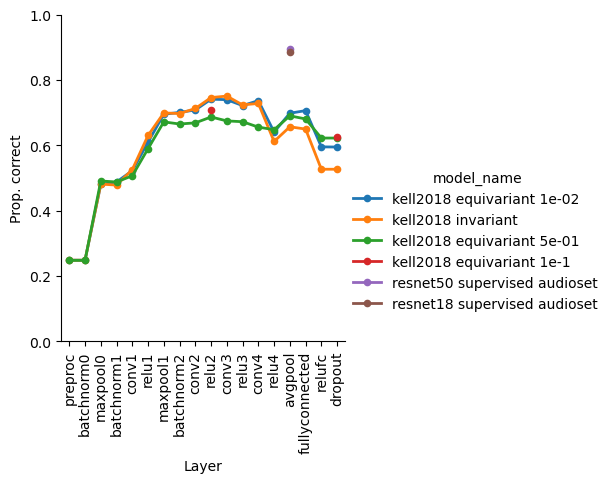

In [122]:
g = sns.catplot(data=df, kind='point', x='test_layer', y='overall_acc', hue="model_name", height=4, lw=2, ms=4)
g.set_xticklabels(rotation=90)
g.set(ylim=(0, 1), ylabel='Prop. correct', xlabel='Layer')

/tmp/ipykernel_196990/1845732868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=df[df.test_layer=='avgpool'].sort_values("overall_acc", ascending=False), kind='swarm',


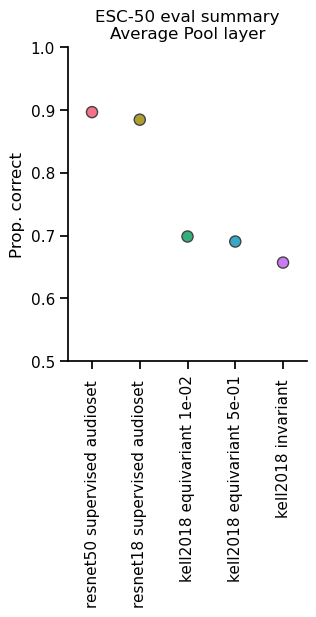

In [170]:

sns.set_context('notebook')
g = sns.catplot(data=df[df.test_layer=='avgpool'].sort_values("overall_acc", ascending=False), kind='swarm',
                y='overall_acc', ls='', x='model_name',
                size=8,
                height=4, aspect=1, 
                palette='husl')

g.set_xticklabels(rotation=90)
g.set(xlabel='', ylabel='Prop. correct', title='ESC-50 eval summary\nAverage Pool layer', ylim=(.5,1) )


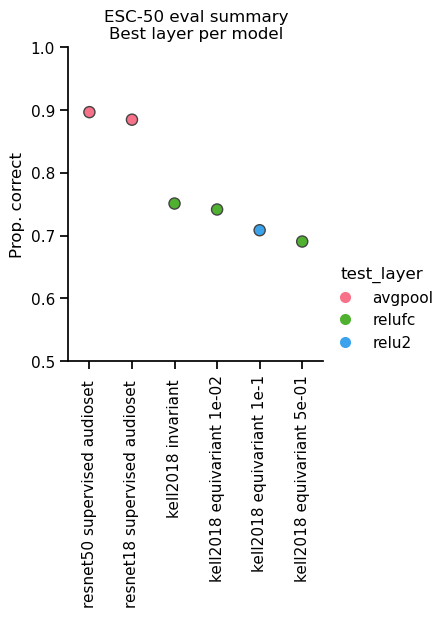

In [172]:
g = sns.catplot(data=df.groupby('model_name').max().sort_values("overall_acc", ascending=False), kind='swarm',
                y='overall_acc', ls='', x='model_name',
                size=8,
                hue='test_layer',
                height=4, aspect=1, 
                palette='husl')
sns.set_context('notebook')

g.set_xticklabels(rotation=90)
g.set(xlabel='', ylabel='Prop. correct', title='ESC-50 eval summary\nBest layer per model', ylim=(.5,1) )

In [ ]:
g = sns.catplot(data=df[df.test_layer=='avgpool'].sort_values("overall_acc", ascending=False), kind='point', x='overall_acc', y='model_name',height=4)
g.set_xticklabels(rotation=90)


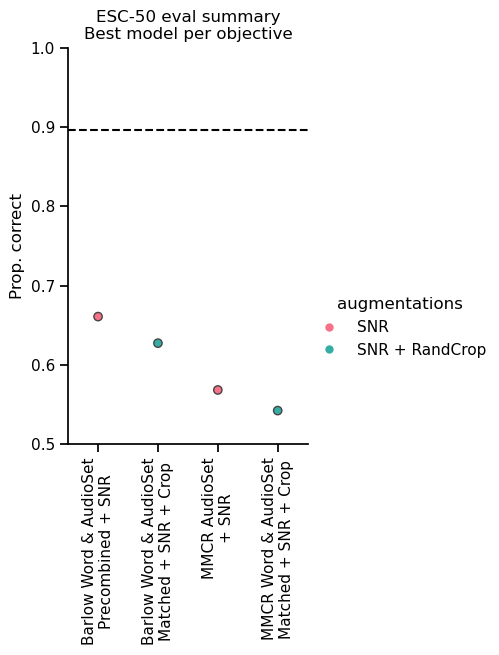

In [14]:
# Get best models from each set 
losses = ['cross_ent', 'mmcr', 'barlow']
wanted_models = ["pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched__best_val_ckpt_avgpool", 
                "pilot_ssl_mmcr_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched__best_val_ckpt_avgpool"]
for loss in losses:
    wanted_models.append(df[(df.loss == loss) & (df.test_layer == 'avgpool')].sort_values('overall_acc', ascending=False).iloc[0, 0])

plot_name_dict = {
    'pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched__best_val_ckpt_avgpool': "Barlow Word & AudioSet\nMatched + SNR + Crop",
    'pilot_ssl_mmcr_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched__best_val_ckpt_avgpool':  "MMCR Word & AudioSet\nMatched + SNR + Crop",
    'audioset_resnet50_avgpool': "Supervised AudioSet\n+ SNR",
    'ssl_mmcr_audioset_resnet50_hparam_set_0_avgpool': "MMCR AudioSet\n+ SNR",
    'pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_avgpool' : "Barlow Word & AudioSet\nPrecombined + SNR"
}


to_plot = df[df.model_name.isin(wanted_models)].sort_values('overall_acc', ascending=False)
to_plot['plot_name'] = to_plot.model_name.map(plot_name_dict)
to_plot.loc[to_plot.model_name.str.contains('Matched'), 'augmentations'] = "SNR + RandCrop"
to_plot.loc[~to_plot.model_name.str.contains('Matched'), 'augmentations'] = "SNR"



sns.set_context('notebook')

g= sns.catplot(data=to_plot[to_plot.loss!='cross_ent'], x='plot_name',# order=['cross_ent', 'barlow', 'mmcr'],
                y='overall_acc', hue='augmentations',
                kind='swarm',
                ls='', size=6,
                height=5, aspect=.75, 
                palette='husl')
g.set_xticklabels(rotation=90)
g.set(xlabel='', ylabel='Prop. correct', title='ESC-50 eval summary\nBest model per objective', ylim=(.5,1) )
g.axes[0][0].axhline(y=to_plot[to_plot.loss=='cross_ent'].overall_acc.values, color='k', ls='--', label='best supervised model')
